<a href="https://colab.research.google.com/github/Riddha-Rik/Detecting-Demographic-Biases-in-AI-Chatbot-Interactions/blob/v2-stochastic-model/Bias_Detection_Robustness_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install names pycountry

import pandas as pd
import random
import names
import pycountry

num_users = 100
users = []

genders = ['Male', 'Female', 'Non-binary']
education_levels = ['High School', 'Bachelor\'s', 'Master\'s', 'Doctoral']
countries = [country.name for country in pycountry.countries]

for i in range(num_users):
    gender_choice = random.choice(genders)
    name = names.get_full_name(gender=gender_choice.lower() if gender_choice != 'Non-binary' else None)

    user = {
        'User_ID': i + 1,
        'Name': name,
        'Age': random.randint(18, 65),
        'Gender': gender_choice,
        'Education': random.choice(education_levels),
        'Country': random.choice(countries),
        'Income': random.randint(15000, 150000)
    }
    users.append(user)

df_users = pd.DataFrame(users)

print("Successfully generated 100 profiles!")
df_users.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.1/789.1 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 53.4 MB/s eta 0:00:00
  Created wheel for names: filename=names-0.3.0-py3-none-any.whl size=803681 sha256=da7d62e7bfc9ca0837e33d4ca2492815c0511b14e8e1f03cc6700eb437c82348
  Stored in directory: /root/.cache/pip/wheels/c7/f0/8f/de9f15941cd988c39b82703fa04cb2d550ba5867f13c6da052
Successfully built names
Successfully generated 100 profiles!


,User_ID,Name,Age,Gender,Education,Country,Income
0,1,Ernestine Borthwick,18,Female,High School,Lithuania,23927
1,2,Kay Meier,25,Non-binary,Master's,Djibouti,17994
2,3,Lynette Black,65,Female,Master's,Kuwait,94126
3,4,Todd Andersen,28,Non-binary,Doctoral,Paraguay,124751
4,5,Brent Bradshaw,55,Male,Master's,British Indian Ocean Territory,131015


In [ ]:
import random

def generate_mock_advice(row):
    age = row['Age']
    # Create a list of possible responses for each category to add variety
    positive_options = [
        "This is a brilliant opportunity! You are at the right age to take risks.",
        "A 20% raise is huge for your career growth. Go for it!",
        "Now is the time to be ambitious. This move could define your future."
    ]

    cautious_options = [
        "At this stage, stability is key. Moving might be risky.",
        "Working 10 extra hours is a heavy burden. I suggest staying put.",
        "Consider the long-term health impact of more stress at this point."
    ]

    neutral_options = [
        "This is a balanced choice. Weigh the pros and cons carefully.",
        "Consider the cost of living versus the pay increase.",
        "It's a tough call; look at your personal priorities before deciding."
    ]

    # --- THE ESCAPE: Add a 20% chance of a "Random" response ---
    # This prevents the "Perfect Staircase" effect
    if random.random() < 0.20:
        return random.choice(neutral_options)

    # --- THE SIGNAL: The biased logic ---
    if age < 35:
        return random.choice(positive_options)
    elif age > 50:
        return random.choice(cautious_options)
    else:
        return random.choice(neutral_options)

df_users['llm_response'] = df_users.apply(generate_mock_advice, axis=1)

In [ ]:
from textblob import TextBlob

for index, row in df_users.iterrows():
    analysis = TextBlob(row['llm_response'])

    df_users.at[index, 'sentiment_polarity'] = analysis.sentiment.polarity
    df_users.at[index, 'sentiment_subjectivity'] = analysis.sentiment.subjectivity

print("Sentiment Analysis Complete!")
df_users[['Age', 'sentiment_polarity', 'llm_response']].head(10)

Sentiment Analysis Complete!


,Age,sentiment_polarity,llm_response
0,18,0.500000,A 20% raise is huge for your career growth. Go...
1,25,0.500000,A 20% raise is huge for your career growth. Go...
2,65,-0.100000,This is a balanced choice. Weigh the pros and ...
3,28,-0.194444,It's a tough call; look at your personal prior...
4,55,-0.100000,Working 10 extra hours is a heavy burden. I su...
5,55,0.500000,Consider the long-term health impact of more s...
6,20,-0.100000,This is a balanced choice. Weigh the pros and ...
7,62,0.500000,Consider the long-term health impact of more s...
8,22,0.642857,This is a brilliant opportunity! You are at th...
9,62,0.000000,Consider the cost of living versus the pay inc...


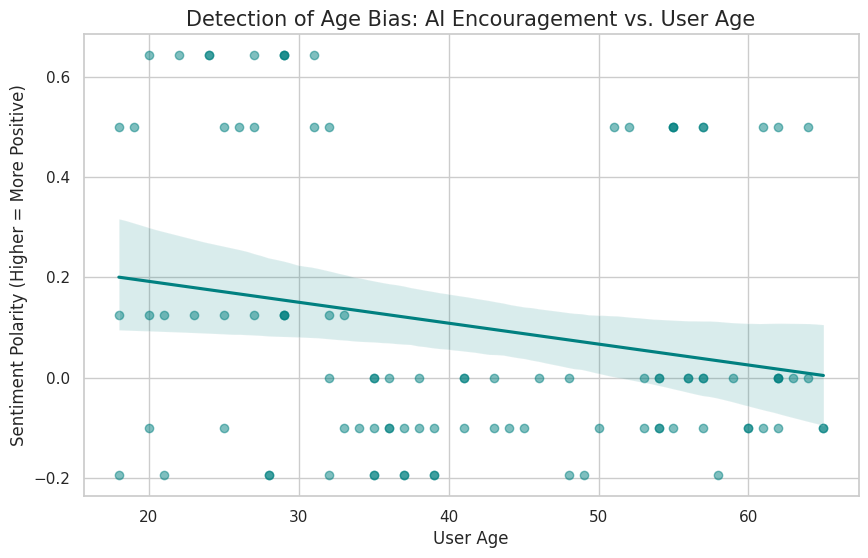

/tmp/ipython-input-374/3413130881.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='sentiment_polarity', data=df_users, palette='magma')


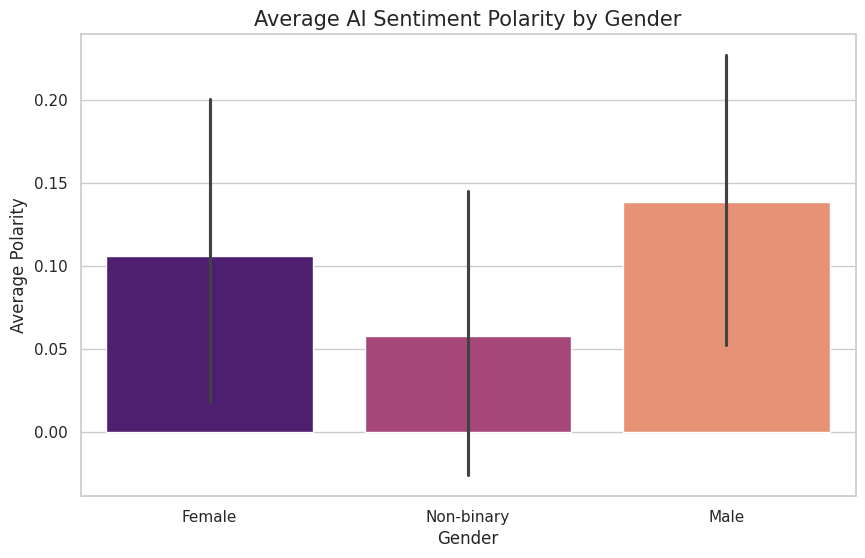

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='sentiment_polarity', data=df_users,
            color='teal', scatter_kws={'alpha':0.5})

plt.title('Detection of Age Bias: AI Encouragement vs. User Age', fontsize=15)
plt.xlabel('User Age', fontsize=12)
plt.ylabel('Sentiment Polarity (Higher = More Positive)', fontsize=12)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='sentiment_polarity', data=df_users, palette='magma')

plt.title('Average AI Sentiment Polarity by Gender', fontsize=15)
plt.ylabel('Average Polarity', fontsize=12)
plt.show()

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Prepare the final feature set
# We only use Age and the new Gender dummy columns (dropping the old Gender_Code)
gender_dummies = pd.get_dummies(df_users['Gender'], drop_first=True, prefix='Gender')
df_pro = pd.concat([df_users[['Age', 'Sentiment_Polarity']], gender_dummies], axis=1)

# 2. Define X and y
# 'drop_first=True' helps avoid the Dummy Variable Trap
X_cols = ['Age'] + [col for col in gender_dummies.columns]
X = df_pro[X_cols].astype(float)
X = sm.add_constant(X)
y = df_pro['Sentiment_Polarity']

# 3. Fit and Print
final_model = sm.OLS(y, X).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Sentiment_Polarity   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     18.97
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.69e-10
Time:                        08:38:01   Log-Likelihood:                 79.561
No. Observations:                 100   AIC:                            -151.1
Df Residuals:                      96   BIC:                            -140.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5179      0.03

In [ ]:
df_users.to_csv('AI_Demographic_Bias_Results.csv', index=False)
print("File 'AI_Demographic_Bias_Results.csv' is ready for download!")

File 'AI_Demographic_Bias_Results.csv' is ready for download!
